### Gyroscope orientation

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.load import load_position
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd

from spyglass.common.common_behav import RawPosition
from spyglass.common.common_behav import VideoFile
import os

[2025-11-23 14:26:13,085][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

In [4]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter

In [5]:
def return_gyro_trial(nwbf, t0, t1):
    # gyro
    gyrodata=nwbf.processing['analog']['analog'].time_series['analog'].data
    gyrotimestamps=nwbf.processing['analog']['analog'].time_series['analog'].timestamps
    
    timestamp_ind = np.logical_and(gyrotimestamps >= t0, gyrotimestamps <= t1)
    gyro_data_trial = gyrodata[timestamp_ind].astype("float64")
    gyro_time_trial = gyrotimestamps[timestamp_ind]

    return gyro_time_trial, gyro_data_trial

In [6]:
### 
### 1. Load Gyro data
### 2. Load animal position
### 3. Call Trodestrack to interpolate
###

In [7]:
nwb_file_name = 'lewis20240109.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

In [8]:
# session information
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
session_name = session_interval[0]
pos_name = position_interval[0]

q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(0.1),
     "delta_t_minus":5,
     "delta_t_plus":5}
                    
log_df = ChangeofMindTheta().fetch1_dataframe(q)
trialIDs = log_df.index
(t0,t1) = (log_df.loc[trialIDs[10]].timestamp_H, 
           log_df.loc[trialIDs[10]].timestamp_O)

In [9]:
# nwb
io = pynwb.NWBHDF5IO('/stelmo/nwb/raw/'+nwb_file_name,'r')
nwbf = io.read()

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cach

In [10]:
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

#### 1. Use range of data to determine which channels are Gyroscope or Accelerameter

Accelerometer (±2g range)

ACCEL_SCALE = 0.000061  # g per LSB (2/32767)

accel_g = raw_value * 0.000061

accel_m_s2 = accel_g * 9.80665

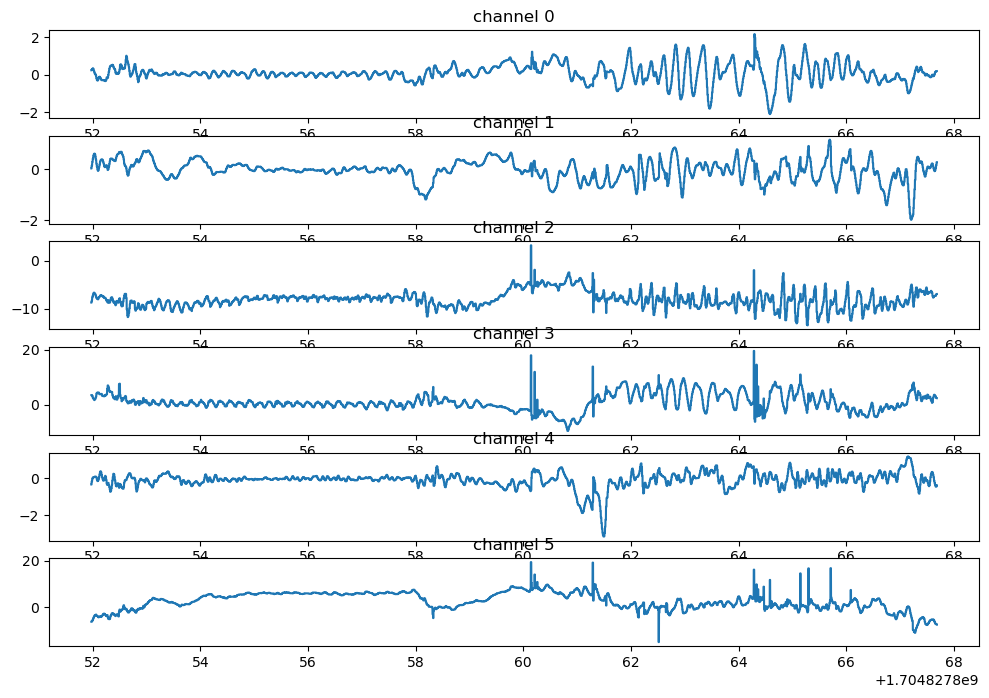

In [11]:
fig, axes = plt.subplots(6,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyro_data_trial[:,i] * 0.000061 * 9.80665)
    axes[i].set_title(f"channel {i}")

#### From the range, we see that Accelerameter is channel 0, 1, 4

Gyroscope (±2000 deg/s range)

GYRO_SCALE = 0.061  # deg/s per LSB (2000/32767)

gyro_deg_s = raw_value * 0.061

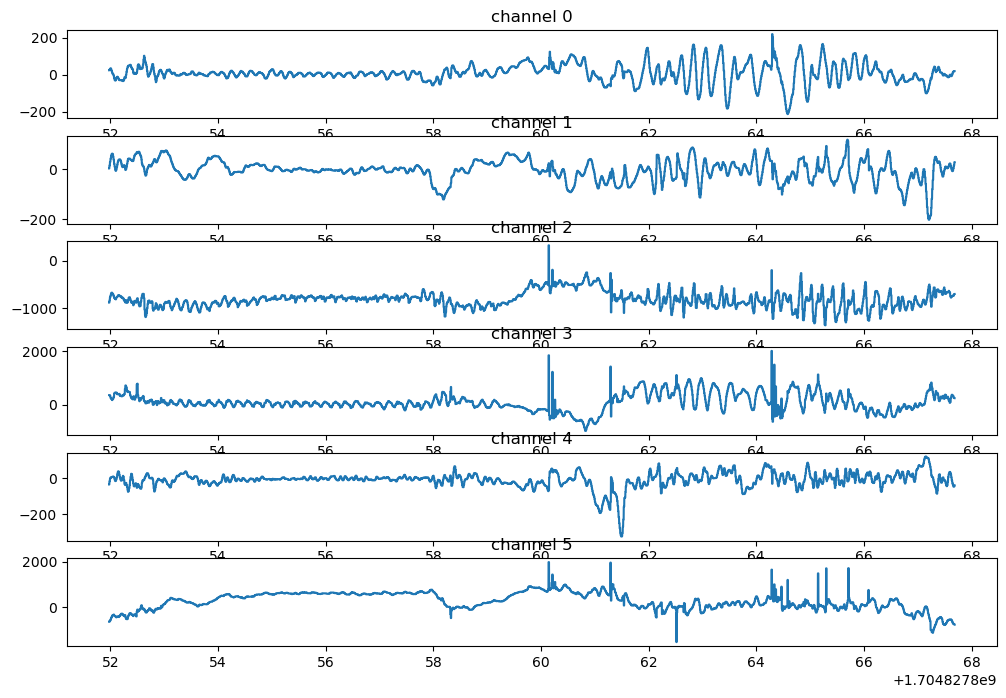

In [12]:
fig, axes = plt.subplots(6,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyro_data_trial[:,i] * 0.061)
    axes[i].set_title(f"channel {i}")

#### From the range, we see that Accelerameter is channel 0, 1, 4
#### Gyroscope is channel 2, 3, 5

In [13]:
# Gyro X, Gyro Y, Gyro Z: 2 3 5
# Accel X, Accel Y, Accel Z: 0 1 4

### 2. Determine orientation:
The SpikeGadgets headstage uses a right-handed coordinate system. The physical orientation of the axes depends on how the headstage is mounted on the animal.

In [14]:
# pack data into Parquet
from trodestrack.data.analyze_imu_orientation import analyze_imu_orientation

In [15]:
(t0,t1) = (log_df.loc[trialIDs[10]].timestamp_H, 
           log_df.loc[trialIDs[40]].timestamp_O)
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

In [16]:
df = pd.DataFrame({"Headstage_GyroX": gyro_data_trial[:,2],
                   "Headstage_GyroY": gyro_data_trial[:,3],
                   "Headstage_GyroZ": gyro_data_trial[:,5],
                   "Headstage_AccelX": gyro_data_trial[:,0],
                   "Headstage_AccelY": gyro_data_trial[:,1],
                   "Headstage_AccelZ": gyro_data_trial[:,4]},
                   index = gyro_time_trial)


table = pa.Table.from_pandas(df)
imu_file = f'/cumulus/shijie/gyro/imu_{nwb_file_name}.parquet'
pq.write_table(table, imu_file)

In [17]:
# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
raw_position = RawPosition.PosObject & key
spatial_series = raw_position.fetch_nwb()[0]["raw_position"]
spatial_df = raw_position.fetch1_dataframe()
spatial_subset_df = select_subset_helper_pd(spatial_df, (t0,t1))
spatial_subset_df = spatial_subset_df.rename(
     columns={'xloc': 'xloc2','yloc': 'yloc2',
             'xloc2': 'xloc','yloc2': 'yloc'})
meters_per_pixel = spatial_series.conversion

[2025-11-23 14:27:18,945][WARNING]: Skipped checksum for file with hash: e630fc87-b027-ed25-8410-26bf159c7e37, and path: /stelmo/nwb/raw/lewis20240109_.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_0' has data shape (30647, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to 

In [18]:
spatial_subset_df_cleaned = spatial_subset_df.dropna()

In [19]:
spatial_subset_df_cleaned

,video_frame_ind,non_repeat_timestamp_labels,xloc,yloc,xloc2,yloc2
time,,,,,,
1.704828e+09,7954.0,1.0,820.0,942.0,825.0,912.0
1.704828e+09,7955.0,1.0,821.0,942.0,827.0,913.0
1.704828e+09,7956.0,1.0,821.0,942.0,827.0,914.0
1.704828e+09,7957.0,1.0,821.0,942.0,828.0,915.0
1.704828e+09,7958.0,1.0,821.0,942.0,827.0,915.0
...,...,...,...,...,...,...
1.704829e+09,30291.0,1.0,761.0,205.0,757.0,223.0
1.704829e+09,30292.0,1.0,762.0,206.0,758.0,223.0
1.704829e+09,30293.0,1.0,761.0,206.0,758.0,223.0


In [20]:
table = pa.Table.from_pandas(spatial_subset_df_cleaned)

pos_file = f'/cumulus/shijie/gyro/position_{nwb_file_name}.parquet'
pq.write_table(table, pos_file)

In [226]:
analyze_imu_orientation(pos_file, imu_file, meters_per_pixel)

IMU AXIS ORIENTATION ANALYSIS

Loading data...
✓ Camera: 385 frames
✓ IMU: 3,378 samples

STEP 1: IDENTIFY VERTICAL AXIS (GRAVITY)

Accelerometer mean values:
  Accel X:   +0.09 ± 0.50 m/s²
  Accel Y:   -0.06 ± 0.41 m/s²
  Accel Z:   -0.11 ± 0.42 m/s² ← GRAVITY AXIS

3D magnitude: 0.15 m/s² (expected ~9.81 m/s²)

✓ Vertical axis: Z (aligned with gravity)
  Sign: negative = pointing upward in body frame

STEP 2: IDENTIFY YAW AXIS (HEADING RATE)

Method 1: Correlation of each gyro axis with heading rate from camera:
  Gyro X: r = -0.033
  Gyro Y: r = +0.019
  Gyro Z: r = -0.083

Method 2: Gyro variance (indicates which axes are most active):
  Gyro X: σ = 171.9 deg/s
  Gyro Y: σ = 325.2 deg/s
  Gyro Z: σ = 384.5 deg/s

Method 3: Physical expectation:
  → Yaw rotation should be around vertical axis: Z

✓ Yaw axis: Gyro Z (matches vertical axis)
  Correlation with heading: -0.083
  Sign: negative gyro = counterclockwise rotation

STEP 3: CORRELATE HORIZONTAL ACCEL WITH CAMERA MOTION

Corre

### Prepare for tracking

In [22]:
from trodestrack.data.load_arthur_session import load_arthur_session

In [234]:
trial_ind = 10
trialID = trialIDs[trial_ind]
(t0,t1) = (log_df.loc[trialID].timestamp_H, 
           log_df.loc[trialID].timestamp_O)
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

df = pd.DataFrame({"Headstage_GyroX": gyro_data_trial[:,2],
                   "Headstage_GyroY": gyro_data_trial[:,3],
                   "Headstage_GyroZ": gyro_data_trial[:,5],
                   "Headstage_AccelX": gyro_data_trial[:,0],
                   "Headstage_AccelY": gyro_data_trial[:,1],
                   "Headstage_AccelZ": gyro_data_trial[:,4]},
                   index = gyro_time_trial)


table = pa.Table.from_pandas(df)
imu_file = f'/cumulus/shijie/gyro/imu_{nwb_file_name}_{session_name}_trial{trialID}.parquet'
pq.write_table(table, imu_file)

# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
raw_position = RawPosition.PosObject & key
spatial_series = raw_position.fetch_nwb()[0]["raw_position"]
spatial_df = raw_position.fetch1_dataframe()
spatial_subset_df = select_subset_helper_pd(spatial_df, (t0,t1))
spatial_subset_df = spatial_subset_df.dropna()
spatial_subset_df.video_frame_ind = spatial_subset_df.video_frame_ind-np.array(
    spatial_subset_df.video_frame_ind)[0]

spatial_subset_df = spatial_subset_df.rename(
     columns={'xloc': 'xloc2','yloc': 'yloc2',
             'xloc2': 'xloc','yloc2': 'yloc'})

table = pa.Table.from_pandas(spatial_subset_df_renamed)

pos_file = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}.parquet'
pq.write_table(table, pos_file)

meters_per_pixel = spatial_series.conversion

[2025-11-24 10:17:08,758][WARNING]: Skipped checksum for file with hash: e630fc87-b027-ed25-8410-26bf159c7e37, and path: /stelmo/nwb/raw/lewis20240109_.nwb
[2025-11-24 10:17:08,783][WARNING]: Skipped checksum for file with hash: e630fc87-b027-ed25-8410-26bf159c7e37, and path: /stelmo/nwb/raw/lewis20240109_.nwb


In [228]:
data = load_arthur_session(pos_file, imu_file,
    verbose = True,
    imu_mode = "3d",  # Use full 6-axis IMU
    meters_per_pixel = meters_per_pixel,
)

LOADING ARTHUR SESSION

Raw data:
  Position: 385 frames
  IMU: 471,241 samples (with sample-and-hold)

Sample-and-hold removal:
  Unique samples: 1,643
  Repeat factor: 286.8×

Sampling rates:
  IMU: 100.0 Hz
  Camera: 24.5 Hz

Duration:
  IMU: 15.7 s (0.3 min)
  Camera: 15.7 s (0.3 min)
  Time overlap: 15.7 s

Unit conversions (IMU mode: 3d):
  Gyro X: [-1370.7, 327.7] deg/s
  Gyro Y: [-974.1, 1996.7] deg/s
  Gyro Z: [-1533.7, 1976.9] deg/s
  Accel X: [-1.98, 1.14] m/s²
  Accel Y: [-2.09, 1.97] m/s²
  Accel Z: [-3.16, 1.15] m/s²
  LED separation: 7.04 cm
  Arena: 0.52 × 1.69 m

Data quality check:
  3D accel magnitude: 0.62 m/s² (expected ~9.81)

✓ Data ready for trodestrack



### TrodesTracking

In [184]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter

In [252]:
# Load data with 2D IMU mode

# Configure EKF for 2D camera + 3D IMU
ekf_config = EKFConfig(
    state_mode="2d_cam_3d_imu",  # 10D state
    process_noise_pos=0.02,
    process_noise_vel=2.0,
    process_noise_gyro_bias=2e-6,#2e-6,
    process_noise_accel_bias=2e-4,
    measurement_noise_pos=0.005**2,
    damping_coeff=0.1,
    led_distance=data.led_distance,
)

# Run filter
result = extended_kalman_filter(
    ekf_config=ekf_config,
    t_imu=data.t_imu,
    U_imu=data.U_imu,  # [N × 10] for 3D mode
    t_cam=data.t_cam,
    Z_cam_led1=data.Z_cam_led1, # front?
    Z_cam_led2=data.Z_cam_led2, # back?
    mask_cam=data.mask_cam,
)

In [253]:
X_est = np.array(result.filtered_means)
P_est = np.array(result.filtered_covariances)

In [254]:
len(X_est)

385

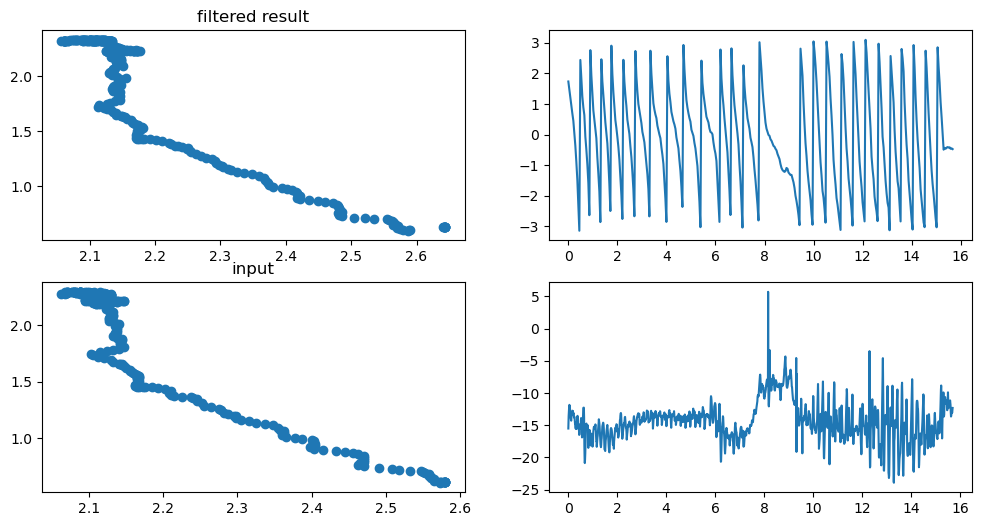

In [255]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
axes[0,0].set_title("filtered result")
axes[0,0].scatter(X_est[:,0], X_est[:,1])
axes[0,1].plot(data.t_cam, X_est[:,5])
axes[1,0].set_title("input")
axes[1,0].scatter(data.Z_cam_led1[:,0], data.Z_cam_led1[:,1])
axes[1,1].plot(data.t_imu, data.U_imu[:,0])

### Make video

In [149]:
from trodestrack.data.visualize_session import create_video_overlay
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast

from trodestrack.data.load_arthur_session import load_video_frame

In [150]:
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4

In [168]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_0' has data shape (30647, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/shijiegu/anaconda3

In [169]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trialID}'
make_mp4(cap, timestamps, t0, t1, outputName)

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


'position_lewis20240109.nwb_02_Rev2Session1_trial11_rawposition.mp4'

In [218]:
create_video_overlay(
    video_path = outputName + '_rawposition.mp4',
    data = data,
    position_df = spatial_subset_df,
    output_path = "overlay_3DIMU.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0,
    gyro_ylim=(-200, 200),    # deg/s
    accel_ylim=(-15, 15)      # m/s²
)


CREATING VIDEO VISUALIZATION

Input video: position_lewis20240109.nwb_02_Rev2Session1_trial11_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 25.0 fps
  Duration: 15.4 s

Output: overlay_3DIMU.mp4
  Start time: 0.0 s
  Duration: 15.7 s
  Output fps: 25.0

  Adjusted duration to 15.4s

Generating 384 frames...

✓ Video saved to: overlay_3DIMU.mp4


In [211]:
create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = data,
    filter_result = result,
    t_filter = data.t_cam,
    position_df = spatial_subset_df,
    output_path = "filter.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)


FAST FILTER OVERLAY VIDEO

Input: position_lewis20240109.nwb_02_Rev2Session1_trial11_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 25.0 fps

Output: filter.mp4
  Start: 0.0s, Duration: 15.7s
  Output fps: 25.0

Generating 392 frames...
  Progress: 0/392 frames (0.0%)
  Progress: 30/392 frames (7.7%)
  Progress: 60/392 frames (15.3%)
  Progress: 90/392 frames (23.0%)
  Progress: 120/392 frames (30.6%)
  Progress: 150/392 frames (38.3%)
  Progress: 180/392 frames (45.9%)
  Progress: 210/392 frames (53.6%)
  Progress: 240/392 frames (61.2%)
  Progress: 270/392 frames (68.9%)
  Progress: 300/392 frames (76.5%)
  Progress: 330/392 frames (84.2%)
  Progress: 360/392 frames (91.8%)
  Progress: 390/392 frames (99.5%)

✓ Video saved to: filter.mp4
